In [30]:
import sys
print(sys.executable)

/Users/cdp/opt/anaconda3/envs/GenAIEnv/bin/python


In [31]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

## Define State

In [32]:
class TemperatureState(TypedDict):
    temp_celsicus: float
    temp_fahrenheit: float
    weather_status: str


## Define State and Graph

In [33]:
graph = StateGraph(TemperatureState)


In [34]:
def convert_temp(state: TemperatureState) -> TemperatureState:
    celsius = state["temp_celsicus"]
    fahrenheit = (celsius * 9/5) + 32
    state["temp_fahrenheit"] = round(fahrenheit,2)
    return state 

In [35]:
graph.add_node("convert_temp",convert_temp)

graph.add_edge(START,"convert_temp")
graph.add_edge("convert_temp",END)

## Compile Graph

In [36]:
workflow = graph.compile()

## Execute Graph

In [37]:
initial_state = {
    "temp_celsicus": 28.5}

final_state = workflow.invoke(initial_state)
print(f"Final State: {final_state}")

Final State: {'temp_celsicus': 28.5, 'temp_fahrenheit': 83.3}


## Visualize Graph

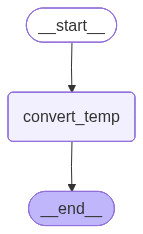

In [38]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())



## Adding the additonal node

In [39]:
def label_weather(state: TemperatureState) -> TemperatureState:
    farenheit = state["temp_fahrenheit"]
    if farenheit < 32:
        state["weather_status"] = "Freezing"
    elif 32 <= farenheit < 50:
        state["weather_status"] = "Cold"
    elif 50 <= farenheit < 70:
        state["weather_status"] = "Mild"
    elif 70 <= farenheit < 90:
        state["weather_status"] = "Warm"
    else:
        state["weather_status"] = "Hot"
    return state

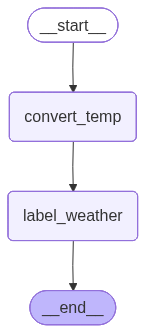

In [40]:
graph = StateGraph(TemperatureState)

graph.add_node("convert_temp",convert_temp)
graph.add_node("label_weather",label_weather)

graph.add_edge(START,"convert_temp")
graph.add_edge("convert_temp","label_weather")
graph.add_edge("label_weather",END)


workflow = graph.compile()

from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())



In [41]:
initial_state = {
    "temp_celsicus": 28.5}

final_state = workflow.invoke(initial_state)
print(f"Final State: {final_state}")

Final State: {'temp_celsicus': 28.5, 'temp_fahrenheit': 83.3, 'weather_status': 'Warm'}
